# Gold Direction Classification Metrics

Reframes each model's next-day gold return prediction as a binary up/down classification problem and reports confusion matrix, precision, recall, F1, and ROC-AUC for the baseline and tuned version of every model.

## 1. Setup and Load Predictions

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

RESULTS_DIR = Path("results")

In [2]:
lasso_predictions = pd.read_csv(
    RESULTS_DIR / "lasso_predictions.csv",
    parse_dates=["Date"]
)
lstm_predictions = pd.read_csv(
    RESULTS_DIR / "lstm_predictions.csv",
    parse_dates=["Date"]
)
xgboost_predictions = pd.read_csv(
    RESULTS_DIR / "xgboost_predictions.csv",
    parse_dates=["Date"]
)

print("Lasso test rows:", len(lasso_predictions))
print("LSTM test rows:", len(lstm_predictions))
print("XGBoost test rows:", len(xgboost_predictions))

Lasso test rows: 753
LSTM test rows: 753
XGBoost test rows: 753


## 2. Convert Returns to Directional Labels

Each model's continuous return prediction is reframed as a binary classification problem: "up" (positive next-day gold return) is the positive class, "down or flat" is the negative class. The actual label comes from the sign of the true return; the predicted label comes from the sign of the predicted return. The raw predicted return is also kept as a continuous score for the ROC curve, since ROC-AUC needs a ranked score rather than a hard 0/1 label.

Both the baseline and tuned version of each model are evaluated, using the exact prediction columns each notebook already exported.

In [3]:
model_versions = {
    "Lasso (Baseline)": (lasso_predictions, "Baseline_Lasso_Prediction"),
    "Lasso (Tuned)": (lasso_predictions, "Tuned_Lasso_Prediction"),
    "LSTM (Baseline)": (lstm_predictions, "Baseline_LSTM_Prediction"),
    "LSTM (Tuned)": (lstm_predictions, "Tuned_LSTM_Prediction"),
    "XGBoost (Baseline)": (xgboost_predictions, "Baseline_XGBoost_Prediction"),
    "XGBoost (Tuned)": (xgboost_predictions, "Tuned_XGBoost_Prediction"),
}

classification_data = {}

for model_name, (predictions_df, prediction_column) in model_versions.items():
    actual_return = predictions_df["Actual_Return"].to_numpy()
    predicted_return = predictions_df[prediction_column].to_numpy()

    actual_label = (actual_return > 0).astype(int)
    predicted_label = (predicted_return > 0).astype(int)

    classification_data[model_name] = {
        "actual_label": actual_label,
        "predicted_label": predicted_label,
        "predicted_score": predicted_return,
    }

print("Prepared labels for:", list(classification_data.keys()))

Prepared labels for: ['Lasso (Baseline)', 'Lasso (Tuned)', 'LSTM (Baseline)', 'LSTM (Tuned)', 'XGBoost (Baseline)', 'XGBoost (Tuned)']


### 2.1 Majority-Class Baseline

As a sanity check, this computes what a classifier achieves by always predicting the majority class ("up"), with no information about any feature. This is the classification equivalent of the zero-return baseline used in the regression notebooks. Any model that fails to clearly beat this baseline is providing little practical value over doing nothing.

In [4]:
reference_actual_label = classification_data["Lasso (Tuned)"]["actual_label"]

majority_class = int(round(reference_actual_label.mean()))
majority_predicted_label = np.full_like(reference_actual_label, majority_class)

majority_cm = confusion_matrix(
    reference_actual_label,
    majority_predicted_label,
    labels=[0, 1]
)
majority_tn, majority_fp, majority_fn, majority_tp = majority_cm.ravel()

majority_accuracy = accuracy_score(reference_actual_label, majority_predicted_label)
majority_precision = precision_score(
    reference_actual_label, majority_predicted_label, zero_division=0
)
majority_recall = recall_score(
    reference_actual_label, majority_predicted_label, zero_division=0
)
majority_f1 = f1_score(reference_actual_label, majority_predicted_label, zero_division=0)

print("Majority class:", "Up" if majority_class == 1 else "Down")
print(f"Accuracy: {majority_accuracy:.4f}")
print(f"Precision: {majority_precision:.4f}")
print(f"Recall: {majority_recall:.4f}")
print(f"F1: {majority_f1:.4f}")

Majority class: Up
Accuracy: 0.5618
Precision: 0.5618
Recall: 1.0000
F1: 0.7194


## 3. Confusion Matrices

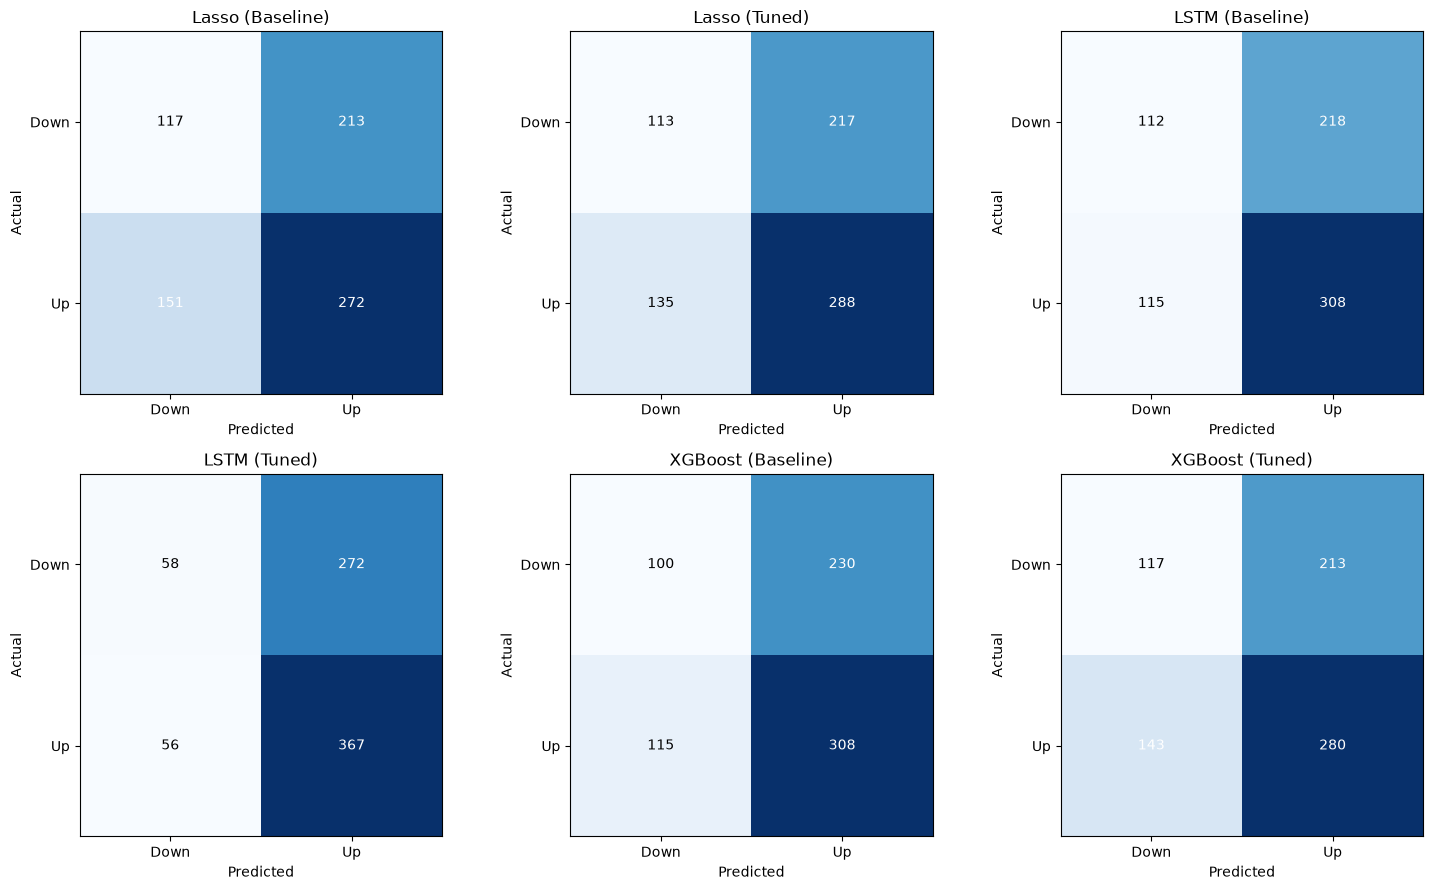

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, (model_name, data) in zip(axes.flat, classification_data.items()):
    cm = confusion_matrix(
        data["actual_label"],
        data["predicted_label"],
        labels=[0, 1]
    )

    ax.imshow(cm, cmap="Blues")
    ax.set_title(model_name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Down", "Up"])
    ax.set_yticklabels(["Down", "Up"])

    for row in range(2):
        for col in range(2):
            ax.text(
                col, row, cm[row, col],
                ha="center", va="center",
                color="white" if cm[row, col] > cm.max() / 2 else "black"
            )

plt.tight_layout()
plt.show()

## 4. Classification Metrics Table

In [6]:
classification_rows = []

for model_name, data in classification_data.items():
    actual_label = data["actual_label"]
    predicted_label = data["predicted_label"]
    predicted_score = data["predicted_score"]

    cm = confusion_matrix(actual_label, predicted_label, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    accuracy = accuracy_score(actual_label, predicted_label)
    precision = precision_score(actual_label, predicted_label, zero_division=0)
    recall = recall_score(actual_label, predicted_label, zero_division=0)
    f1 = f1_score(actual_label, predicted_label, zero_division=0)
    roc_auc = roc_auc_score(actual_label, predicted_score)

    classification_rows.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1_Score": f1,
        "ROC_AUC": roc_auc,
        "True_Positive": tp,
        "True_Negative": tn,
        "False_Positive": fp,
        "False_Negative": fn,
    })

# Majority-class baseline: always predicts the majority class, with no
# ranking of days by confidence, so ROC-AUC is not defined for it.
classification_rows.append({
    "Model": "Majority-Class Baseline",
    "Accuracy": majority_accuracy,
    "Precision": majority_precision,
    "Recall": majority_recall,
    "F1_Score": majority_f1,
    "ROC_AUC": np.nan,
    "True_Positive": majority_tp,
    "True_Negative": majority_tn,
    "False_Positive": majority_fp,
    "False_Negative": majority_fn,
})

classification_metrics = pd.DataFrame(classification_rows).sort_values(
    by="F1_Score",
    ascending=False
).reset_index(drop=True)

classification_metrics

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC,True_Positive,True_Negative,False_Positive,False_Negative
0,Majority-Class Baseline,0.561753,0.561753,1.000000,0.719388,NaN,423,0,330,0
1,LSTM (Tuned),0.564409,0.574335,0.867612,0.691149,0.535855,367,58,272,56
2,LSTM (Baseline),0.557769,0.585551,0.728132,0.649104,0.528211,308,112,218,115
3,XGBoost (Baseline),0.541833,0.572491,0.728132,0.640999,0.516570,308,100,230,115
4,Lasso (Tuned),0.532537,0.570297,0.680851,0.620690,0.519364,288,113,217,135
5,XGBoost (Tuned),0.527224,0.567951,0.661939,0.611354,0.511183,280,117,213,143
6,Lasso (Baseline),0.516600,0.560825,0.643026,0.599119,0.523591,272,117,213,151


These metrics should be read against the "Majority-Class Baseline" row above, which always predicts "up" and uses no information about any feature (the classification analogue of the zero-return regression baseline). Because the test set is imbalanced (423 "up" days vs. 330 "down" days, a 56.2% base rate), this trivial baseline scores 56.2% accuracy and an F1 of about 0.719 — and, sorted by F1-score, it actually ranks above every real model here. ROC-AUC (Section 5), which is threshold-independent and robust to this imbalance, is the more reliable metric for judging whether these models actually discriminate between up and down days; the baseline has no ROC-AUC because it never varies its prediction, so there is nothing to rank.

## 5. ROC Curves

Only the tuned version of each model is plotted here to keep the chart readable; the full ROC-AUC for both baseline and tuned versions is in the table above.

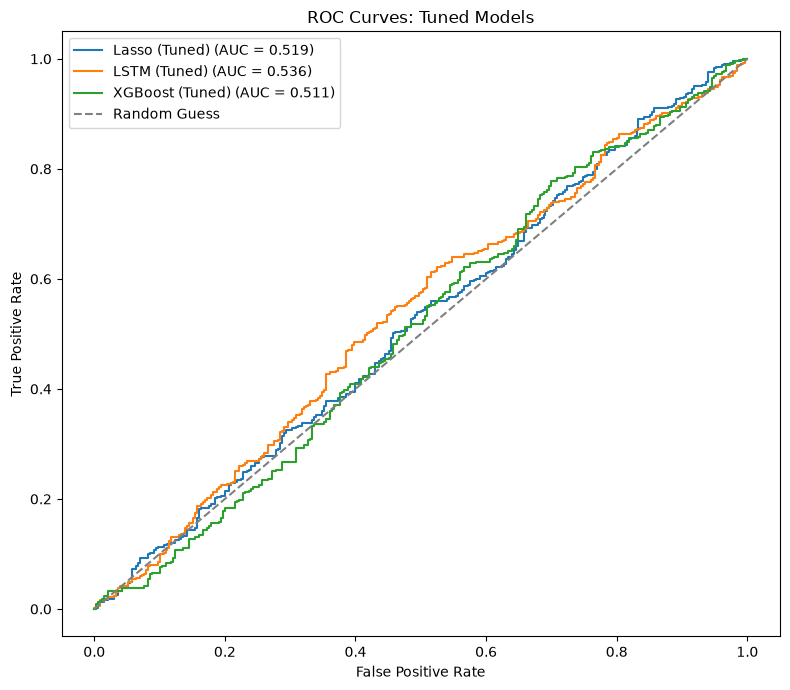

In [7]:
plt.figure(figsize=(8, 7))

tuned_models = {
    name: data for name, data in classification_data.items()
    if "Tuned" in name
}

for model_name, data in tuned_models.items():
    fpr, tpr, _ = roc_curve(data["actual_label"], data["predicted_score"])
    auc = roc_auc_score(data["actual_label"], data["predicted_score"])
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves: Tuned Models")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Export Results

In [8]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

classification_metrics_path = RESULTS_DIR / "classification_metrics.csv"

classification_metrics.to_csv(
    classification_metrics_path,
    index=False
)

print(f"Saved classification metrics to: {classification_metrics_path}")
classification_metrics

Saved classification metrics to: results\classification_metrics.csv


,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC,True_Positive,True_Negative,False_Positive,False_Negative
0,Majority-Class Baseline,0.561753,0.561753,1.000000,0.719388,NaN,423,0,330,0
1,LSTM (Tuned),0.564409,0.574335,0.867612,0.691149,0.535855,367,58,272,56
2,LSTM (Baseline),0.557769,0.585551,0.728132,0.649104,0.528211,308,112,218,115
3,XGBoost (Baseline),0.541833,0.572491,0.728132,0.640999,0.516570,308,100,230,115
4,Lasso (Tuned),0.532537,0.570297,0.680851,0.620690,0.519364,288,113,217,135
5,XGBoost (Tuned),0.527224,0.567951,0.661939,0.611354,0.511183,280,117,213,143
6,Lasso (Baseline),0.516600,0.560825,0.643026,0.599119,0.523591,272,117,213,151


## 7. Conclusion

On the test set (753 days, 423 up / 330 down — a 56.2% base rate for "up"), ranked by F1-score, the Majority-Class Baseline (always predict "up", no information used) scores 56.2% accuracy and an F1 of 0.719 — and outranks every one of the six real model versions on F1. LSTM (Tuned) comes closest (F1 = 0.691, accuracy = 56.4%, the best of the six), but it still falls short of this trivial baseline. Looking at its confusion matrix explains why: it predicts "up" on 639 of 753 days (85%), so its high recall (0.868) largely reflects leaning into the majority class rather than genuine discriminative skill.

ROC-AUC is the more appropriate metric here precisely because it is threshold-independent and not distorted by class imbalance (the majority baseline, by contrast, has no ROC-AUC at all, since a constant prediction gives no ranking to score). By the ROC-AUC measure, every real model sits between 0.511 and 0.536 — barely above the 0.5 line for random guessing, and consistent with the near-zero R² and weak permutation importance found in the regression notebooks. None of the six model versions shows meaningful discriminative power for predicting next-day gold direction.

In a real trading context, the confusion matrices also show that false positives (predicting "up" when gold actually fell) are the dominant error for every model — for LSTM (Tuned), 272 of 330 actual down-days were misclassified as up. These are the costliest mistakes for a directional strategy, since they represent days a trader would have bought and lost money, and they occur far more often than false negatives across all six model versions.

Overall, once the majority-class baseline and class imbalance are accounted for, the classification framing reinforces the same conclusion as the regression analysis: none of the three model families show a reliable, exploitable signal for predicting next-day gold returns, whether framed as a magnitude-prediction or a direction-prediction problem.